# Lab Five: Wide and Deep Network Architectures
Team members: David Guo, Zi Ling

## 1. Preparation

### 1.1 Handel Missing Values, Create Class Feature, and Drop Features


In [1]:
import pandas as pd
from copy import deepcopy

#read data
df_orig = pd.read_csv("medical_insurance.csv")
df = deepcopy(df_orig)

# check missing values
missing_percent = (df.isnull().sum() / len(df)) * 100
missing_percent = missing_percent[missing_percent > 0].sort_values(ascending=False).round(4)
print("missing features and percentage:", missing_percent)
print("==============================================")

# define class variables: annual medical cost levels
# 0: low, 1: medium, 2: high, 3: very high
df["annual_medical_cost_level"] = pd.qcut(df["annual_medical_cost"], q=4, labels=False).astype("int32")
print(df["annual_medical_cost_level"].value_counts())
print("==============================================")

# drop columns not suitable for modeling
df = df.drop(columns = [
	# label leakage features
	"annual_medical_cost", 
	# features with leakage information
	"risk_score", "is_high_risk", "annual_premium",
	 "monthly_premium", "plan_type", "network_tier", "provider_quality", 
	"claims_count", "avg_claim_amount", "total_claims_paid", 
	"deductible", "copay", "policy_term_years", "policy_changes_last_2yrs", 
	"visits_last_year", "hospitalizations_last_3yrs", "days_hospitalized_last_3yrs", 
	"medication_count", "proc_imaging_count","proc_surgery_count", 
	"proc_physio_count", "proc_consult_count", "proc_lab_count", "had_major_procedure", 
	# not useful string
	"person_id",  
	# high missing values 
	"alcohol_freq" 
])



# datatype adjustments
# string categorical
for c in ["sex","region","urban_rural","education","marital_status","employment_status","smoker"]:
	df[c] = df[c].astype(str)
	print(f'{c} has {len(df[c].unique())} unique values.')

# continueous as float
for c in ["systolic_bp","diastolic_bp","ldl","hba1c","age","income","bmi"]:
	df[c] = df[c].astype("float32") #GPT suggested float32 instaed of float
	
# discrete as int
for c in ["household_size","dependents","chronic_count"]:
	df[c] = df[c].astype("int32")
	print(f'{c} has {len(df[c].unique())} unique values.')

# boolean as int
for c in ["hypertension","diabetes","asthma","copd","cardiovascular_disease",
			"cancer_history","kidney_disease","liver_disease","arthritis","mental_health"]:
	df[c] = df[c].astype("int32")
	
print("==============================================")

df.info()
df.head()


missing features and percentage: alcohol_freq    30.083
dtype: float64
annual_medical_cost_level
3    25000
1    25000
2    25000
0    25000
Name: count, dtype: int64
sex has 3 unique values.
region has 5 unique values.
urban_rural has 3 unique values.
education has 6 unique values.
marital_status has 4 unique values.
employment_status has 4 unique values.
smoker has 3 unique values.
household_size has 9 unique values.
dependents has 8 unique values.
chronic_count has 7 unique values.
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 28 columns):
 #   Column                     Non-Null Count   Dtype  
---  ------                     --------------   -----  
 0   age                        100000 non-null  float32
 1   sex                        100000 non-null  object 
 2   region                     100000 non-null  object 
 3   urban_rural                100000 non-null  object 
 4   income                     100000 non-null  float32
 

,age,sex,region,urban_rural,income,education,marital_status,employment_status,household_size,dependents,...,diabetes,asthma,copd,cardiovascular_disease,cancer_history,kidney_disease,liver_disease,arthritis,mental_health,annual_medical_cost_level
0,52.0,Female,North,Suburban,22700.0,Doctorate,Married,Retired,3,1,...,0,0,0,0,0,0,0,1,0,3
1,79.0,Female,North,Urban,12800.0,No HS,Married,Employed,3,1,...,0,0,0,0,0,0,0,1,1,1
2,68.0,Male,North,Rural,40700.0,HS,Married,Retired,5,3,...,0,0,0,0,1,0,0,0,1,3
3,15.0,Male,North,Suburban,15600.0,Some College,Married,Self-employed,5,3,...,1,0,0,0,0,0,0,0,0,3
4,53.0,Male,Central,Suburban,89600.0,Doctorate,Married,Self-employed,2,0,...,0,0,0,0,0,0,0,1,0,1


We select a new dataset named Medical Insurance Cost Prediction from Kaggle(https://www.kaggle.com/datasets/mohankrishnathalla/medical-insurance-cost-prediction) for this lab. This dataset contains 100,000 individual records and 54 features covering six Demographics & Socioeconomic, Lifestyle & Habits,Health & Clinical, Healthcare Utilization & Procedures, Insurance & Policy and Medical Costs & Claims, which provides rich information for our models to learn.

For the predict target, we create a new class variable named "annual_medical_cost_level" derived from annual_medical_cost. This classification helps both customers and insurance companies to have a simple and intuitive understanding on the person's annual medical cost situation. It can also help the insuarance provider and the costomer to choose a suitable insuarance plan. We used qcut to divide the annual medical cost into four balanced classes,  which are 0 as low, 1 as medium, 2 as high, and 3 as very high. Using qcut ensure the balance of thee class sizes, resulting 25,000 record in each class, which prevent model bias toward majority classes.

To have a better model performance and avoid data leakage, we dropped several types of features. First is the feature with missing values, which is alchol_freq, it has 30.083% missing value. Then the leakage risky features, for example, the risk score is generated fro other features, the health utilization and insuarance claim are the result from the individuals condition. We also dropped useless feature, which is person id, because it's a meaningless string compare to other features. 

After dropping the leakage and irrelevant features, the dataset contains 28 input variables. This dimensionality is moderate and does not create significant computational or overfitting concerns for our wide-and-deep network. Therefore, applying dimensionality reduction is not strictly necessary.

After filtering the features, We then correct datatypes of remaining features to prepare for TensorFlow Feature Space preprocessing, with 7 categorical string features to string datatype, 7 contious numerical features to float datatype, and 3 descrete nemerical and 10 bollean features to int datatype.

The final dataset is clean, balanced, and contains 28 meaningful predictive feautres in Demographics & Socioeconomic, Lifestyle & Habits,Health & Clinical, with 100,000 individuals records. All variables have been mapped to appropriate data types to support preprocessing through Keras FeatureSpace.

### 1.2 Train and Test Data Split Before Preprocessing

In [ ]:
import tensorflow as tf

# split Data
from sklearn.model_selection import train_test_split
X = df.drop(columns=["annual_medical_cost_level"])
y = df["annual_medical_cost_level"]

X_train, X_test, y_train, y_test = train_test_split(
	X, y, test_size=0.2, random_state=42, stratify=y # 80-20 split with stratification
)


# create tf.data.Dataset
train_ds = tf.data.Dataset.from_tensor_slices((dict(X_train), y_train)).shuffle(1000).batch(128)
test_ds  = tf.data.Dataset.from_tensor_slices((dict(X_test), y_test)).batch(128)

We divided the dataset using 80/20 stratified train/test split, and this method is appropriate bacause of following reasons:

1. The dataset contains large amount of 100,000 individual records, so even after spliting, the 80% training set still has enough data for the model to learn meaniful patterns, and the 20% test set is also sufficient large to produce a reliable output.

2. Even though our classes are perfectly balanced in full dataset, ramdom sampling can still introduce distribution shifts between the training and test splits. So we applied stratify in the split, to preserves the class proportions excactly and makes the evaluation on the test set more reliable.

3. The individual records in the dataset is independent, no temporal or structural dependencies, so random splitting is approprate and realistic.

4. Although complex splitting stragegies like K-fold cross validation provide benefits, they are better to be used in small dataset. Since our dataset has plenty of data, using complex method won't improve the performance significantly, instead it may slower the process, so 80/20 stratify split is more approprate.

In addition, we split the dataset before preprocessing to prevent data leakage during scaling and embedding.

### 1.3 Using FeatureSpace to Preprocessing and Cross

In [3]:
from keras.utils import FeatureSpace

feature_space = FeatureSpace(
	features={ 

		# string categoricals
		"sex":               FeatureSpace.string_categorical(num_oov_indices=1),
		"region":            FeatureSpace.string_categorical(num_oov_indices=1),
		"urban_rural":       FeatureSpace.string_categorical(num_oov_indices=1),
		"education":         FeatureSpace.string_categorical(num_oov_indices=1),
		"marital_status":    FeatureSpace.string_categorical(num_oov_indices=1),
		"employment_status": FeatureSpace.string_categorical(num_oov_indices=1),
		"smoker":            FeatureSpace.string_categorical(num_oov_indices=1),

		# continuous
		"systolic_bp":       FeatureSpace.float_normalized(),
		"diastolic_bp":      FeatureSpace.float_normalized(),
		"ldl":               FeatureSpace.float_normalized(),
		"hba1c":             FeatureSpace.float_normalized(),
		"age":               FeatureSpace.float_normalized(),
		"income":            FeatureSpace.float_normalized(),
		"bmi":               FeatureSpace.float_normalized(),

		# discretized
		"household_size":    FeatureSpace.float_discretized(num_bins=9),
		"dependents":        FeatureSpace.float_discretized(num_bins=8),
		"chronic_count":     FeatureSpace.float_discretized(num_bins=7),

		# booleans as integer
		"hypertension":          FeatureSpace.float_discretized(num_bins=2),
		"diabetes":              FeatureSpace.float_discretized(num_bins=2),
		"asthma":                FeatureSpace.float_discretized(num_bins=2),
		"copd":                  FeatureSpace.float_discretized(num_bins=2),
		"cardiovascular_disease":FeatureSpace.float_discretized(num_bins=2),
		"cancer_history":        FeatureSpace.float_discretized(num_bins=2),
		"kidney_disease":        FeatureSpace.float_discretized(num_bins=2),
		"liver_disease":         FeatureSpace.float_discretized(num_bins=2),
		"arthritis":             FeatureSpace.float_discretized(num_bins=2),
		"mental_health":         FeatureSpace.float_discretized(num_bins=2),
	},
	crosses=[
		FeatureSpace.cross(
			feature_names=('smoker','mental_health'), 
			crossing_dim=6), # dims: 3 x 2
		FeatureSpace.cross(
			feature_names=('chronic_count','region'), 
			crossing_dim=35),# 7 x 5
		FeatureSpace.cross(
			feature_names=('marital_status','sex'), 
			crossing_dim=12),# 4 x 3
	],
	
	# sex has 3 unique values.
	# region has 5 unique values.
	# urban_rural has 3 unique values.
	# education has 6 unique values.
	# marital_status has 4 unique values.
	# employment_status has 4 unique values.
	# smoker has 3 unique values.
	# household_size has 9 unique values.
	# dependents has 8 unique values.
	# chronic_count has 7 unique values.
	output_mode="concat",
)

train_ds_with_no_labels = train_ds.map(lambda x, _: x)
feature_space.adapt(train_ds_with_no_labels)

preprocessed_ds_train = train_ds.map(lambda feat, labels: (feature_space(feat), labels), num_parallel_calls=tf.data.AUTOTUNE)
preprocessed_ds_train = preprocessed_ds_train.prefetch(tf.data.AUTOTUNE)

preprocessed_ds_test = test_ds.map(lambda feat, labels: (feature_space(feat), labels), num_parallel_calls=tf.data.AUTOTUNE)
preprocessed_ds_test = preprocessed_ds_test.prefetch(tf.data.AUTOTUNE)

We designed three crosses feature groups to provide meaningful interactions between discrete variables:

1. Smoker and mental_health. According to Minichino et al. (2013)[1], people with mental health problems are much more likely to smoke, often using nicotine to cope with anxiety or mood symptoms. This combination makes quitting harder and increases long-term risk for heart and lung diseases. Smoking can also worsen psychiatric symptoms and reduce treatment effectiveness, which further raises medical needs. Because the health impact of these two factors together is much stronger than either one alone, crossing smoker and mental_health helps the model directly capture this high-cost subgroup.

2. Chronic_count and region. Matthews et al. (2020)[2] found that the burden of chronic conditions varies widely across U.S. regions and that the same level of multimorbidity can produce very different medical costs depending on where the patient lives. Regional differences in healthcare access, population health, and medical practice all influence spending. This means chronic disease burden interacts with geography rather than acting alone. Crossing chronic_count and region lets the model learn these region-specific cost patterns instead of forcing it to treat them as independent factors.

3. Marital_status and sex, Robards et al. (2012)[3] showed that being unmarried is linked to poorer health, especially for men. Studies suggest both selection (less healthy men are less likely to marry) and protection (marriage offers men stronger social and health support) effects. As a result, the same marital status can imply very different health risks for men and women. Crossing marital_status and sex allows the model to capture these sex-specific differences in health and expected medical cost.

Together, these crossed features enrich the model’s memorization capability, enabling the wide component to encode interpretable and domain-relevant interactions, while complementing the deep branch that focuses on learning more abstract, non-linear relationships.

For other features we didn't cross, one reason is that we think they are not as important as the three cross groups we have, for example, the household_size, and dependents. The other reason is some features already has straightforward relation to the medical cost, for example,cancer_history, kidney_disease, so we didn't include in this model.

Reference:

[1]A. Minichino et al., “Smoking behaviour and mental health disorders—mutual influences and implications for therapy,” Int. J. Environ. Res. Public Health, vol. 10, no. 10, pp. 4790–4811, Oct. 2013, doi: 10.3390/ijerph10104790.

[2]K. A. Matthews, A. H. Gaglioti, J. B. Holt, L. C. McGuire, and K. J. Greenlund, “County-level concentration of selected chronic conditions among Medicare fee-for-service beneficiaries and its association with Medicare spending in the United States, 2017,” Popul. Health Manag., vol. 24, no. 2, pp. 214–221, Apr. 2021, doi: 10.1089/pop.2019.0231.

[3]J. Robards, M. Evandrou, J. Falkingham, and A. Vlachantoni, “Marital status, health and mortality,” Maturitas, vol. 73, no. 4, pp. 295–299, Dec. 2012, doi: 10.1016/j.maturitas.2012.08.007.

### 1.4 Evaluation metric

We will use the Macro F-beta score with beta = 2 as our main evaluation metric, for the following reasons:

1.	Accuracy only reflects precision and ignores recall, which makes it unsuitable for our task. In medical-cost prediction, missing a high or very high–cost patient is far more serious than misclassifying someone as high-risk, because insurers may not have the enough insurance to save thier life. Therefore, recall must play a central role in our evaluation.

2.	F1-score balances precision and recall, but it treats them equally. In our case, recall should matter more because high-cost patients drive the majority of financial risk and resource planning for insurers. An equal weighting does not reflect this business priority.

3.	A simple F-beta score ( beta = 2) is not ideal in multi-class settings. It is defined for binary classification or for a single target class. Our problem has four cost levels.

4. Macro F-beta (beta = 2) is the correct and practical choice. Because it computes F-beta separately for each of the four classes and then averages the results, giving every class equal weight. Using beta = 2 emphasizes recall—aligning with our goal of avoiding missed high-cost patients—while macro averaging ensures fairness across all cost levels.



## 2. Modelling

### 2.1 Wide and Deep 2 layers Network

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ keras_tensor_53CLO… │ (None, 139)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ model1_deep_dense1  │ (None, 128)       │     17,920 │ keras_tensor_53C… │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ model1_wide_branch  │ (None, 32)        │      4,480 │ keras_tensor_53C… │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ model1_deep_dense2  │ (None, 64)        │      8,256 │ model1_deep_dens… │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ model1_combined     │ (None, 96)        │          0 │ model1_wide_bran… │
│ (Concatenate)       │                   │            │ model1_deep_dens… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ model1_output       │ (None, 4)         │        388 │ model1_combined[… │
│ (Dense)             │                   │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 93,134 (363.81 KB)

 Trainable params: 31,044 (121.27 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 62,090 (242.54 KB)

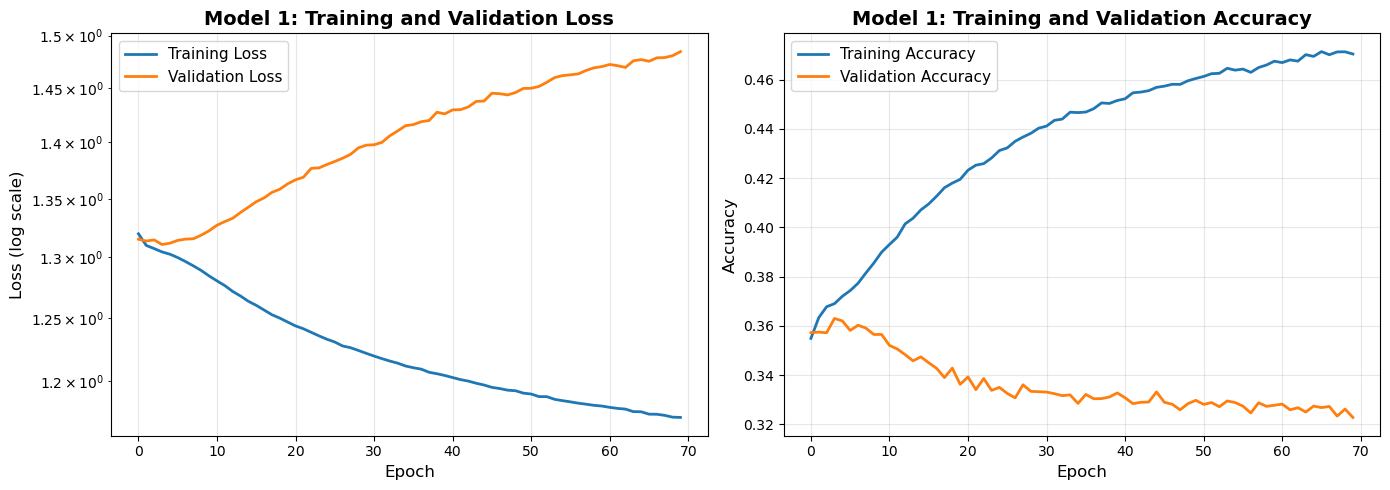

In [4]:
#Asked GPT to help with debugging, and limiting the Epoch print statement
from tensorflow.keras import layers
import matplotlib.pyplot as plt
from tensorflow.keras.callbacks import EarlyStopping

encoded_inputs = feature_space.get_encoded_features()

def model_1(inputs):
	model1_wide_branch = layers.Dense(32, activation="linear", name="model1_wide_branch")(inputs)

	model1_deep = layers.Dense(128, activation="relu", name="model1_deep_dense1")(inputs)
	model1_deep = layers.Dense(64, activation="relu", name="model1_deep_dense2")(model1_deep)

	combined = layers.concatenate([model1_wide_branch, model1_deep], name="model1_combined")
	output = layers.Dense(4, activation="softmax", name="model1_output")(combined)

	model = tf.keras.Model(inputs, output)

	return model

model1 = model_1(encoded_inputs)

model1.compile(
	optimizer="adam",
	loss="sparse_categorical_crossentropy",
	metrics=["accuracy"]
)

history1 = model1.fit(
	preprocessed_ds_train,
	validation_data=preprocessed_ds_test,
	epochs=70,
	verbose=0
)

model1.summary()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Loss plot (log scale)
axes[0].semilogy(history1.history['loss'], label='Training Loss', linewidth=2)
axes[0].semilogy(history1.history['val_loss'], label='Validation Loss', linewidth=2)
axes[0].set_xlabel('Epoch', fontsize=12)
axes[0].set_ylabel('Loss (log scale)', fontsize=12)
axes[0].set_title('Model 1: Training and Validation Loss', fontsize=14, fontweight='bold')
axes[0].legend(fontsize=11)
axes[0].grid(True, alpha=0.3)

# Accuracy plot
axes[1].plot(history1.history['accuracy'], label='Training Accuracy', linewidth=2)
axes[1].plot(history1.history['val_accuracy'], label='Validation Accuracy', linewidth=2)
axes[1].set_xlabel('Epoch', fontsize=12)
axes[1].set_ylabel('Accuracy', fontsize=12)
axes[1].set_title('Model 1: Training and Validation Accuracy', fontsize=14, fontweight='bold')
axes[1].legend(fontsize=11)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


#### Analysis For Model 1

Model 1 is a 2 layer wide and deep network. The wide branch uses 32 neurons which is used to memorize features captured by the preprocess crosses. While the deep branch consists of 2 relu activation dense layer from 128 to 64 neurons, which allows the model to learn nonlinear relationship. In addition, the model uses AdaM optimizer with sparse categorical cross-entropy, which works well with multi classification. 

According to the summary of the model, it contains 31,044 trainable parameters with 0 non trainable parameters. Additional 62,090 parameters are maintained by AdaM to keep track of the first and second moments estimates.

From the graph, we can see that while the training loss is converging, the validation is increasing which immediately shows that the model is overfitting after a few epochs, and this is further supported by the accuracy graph. Indicating that model can memorize patterns, it struggles to extract meaningful features in an unseen dataset. 

### 2.2 4 deep Layers With Dropout

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ keras_tensor_53CLO… │ (None, 139)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ model2_deep_dense1  │ (None, 256)       │     35,840 │ keras_tensor_53C… │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 256)       │          0 │ model2_deep_dens… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ model2_deep_dense2  │ (None, 128)       │     32,896 │ dropout[1][0]     │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 128)       │          0 │ model2_deep_dens… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ model2_deep_dense3  │ (None, 64)        │      8,256 │ dropout_1[1][0]   │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 64)        │      8,960 │ keras_tensor_53C… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ model2_deep_dense4  │ (None, 32)        │      2,080 │ model2_deep_dens… │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 96)        │          0 │ dense[1][0],      │
│ (Concatenate)       │                   │            │ model2_deep_dens… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 4)         │        388 │ concatenate[1][0] │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 265,262 (1.01 MB)

 Trainable params: 88,420 (345.39 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 176,842 (690.79 KB)

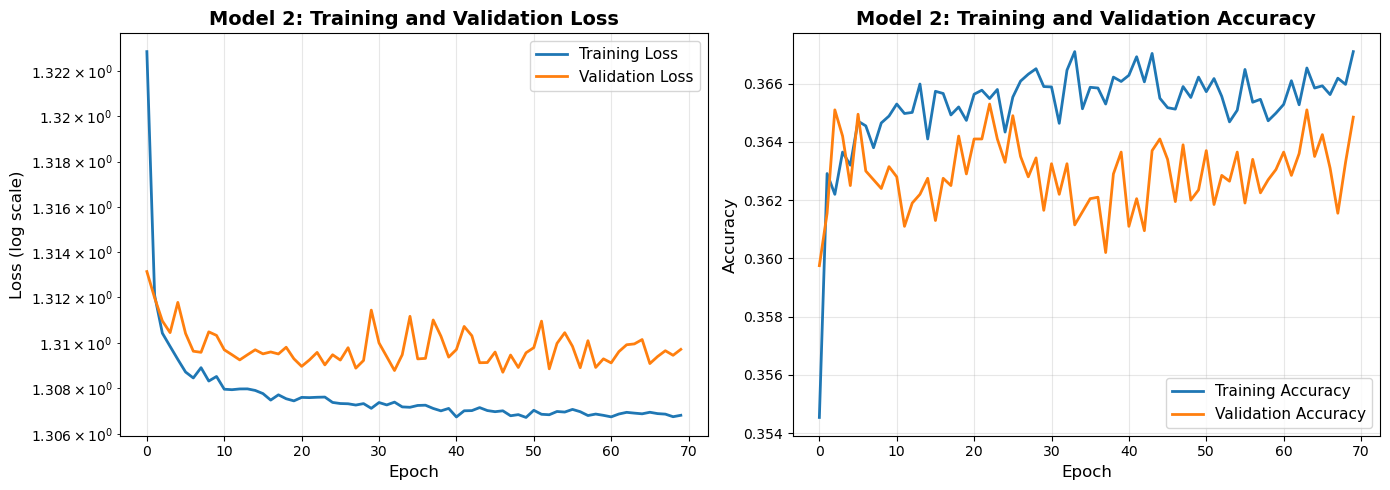

In [5]:
encoded_inputs = feature_space.get_encoded_features()

def model_2(inputs):
	model2_wide_branch = tf.keras.layers.Dense(64, activation="linear")(inputs)

	model2_deep_branch = tf.keras.layers.Dense(256, activation="relu", name="model2_deep_dense1")(inputs)
	model2_deep_branch = tf.keras.layers.Dropout(0.5)(model2_deep_branch)
	model2_deep_branch = tf.keras.layers.Dense(128, activation="relu", name="model2_deep_dense2")(model2_deep_branch)
	model2_deep_branch = tf.keras.layers.Dropout(0.5)(model2_deep_branch)
	model2_deep_branch = tf.keras.layers.Dense(64, activation="relu", name="model2_deep_dense3")(model2_deep_branch)
	model2_deep_branch = tf.keras.layers.Dense(32, activation="relu", name="model2_deep_dense4")(model2_deep_branch)

	combined = tf.keras.layers.concatenate([model2_wide_branch, model2_deep_branch])
	output = tf.keras.layers.Dense(4, activation="softmax")(combined)

	return tf.keras.Model(inputs, output)

model2 = model_2(encoded_inputs)

model2.compile(
	optimizer=tf.keras.optimizers.Adam(learning_rate=0.002),
	loss="sparse_categorical_crossentropy",
	metrics=["accuracy"]
)

history2 = model2.fit(
	preprocessed_ds_train,
	validation_data=preprocessed_ds_test,
	epochs=70,
	verbose=0
)

model2.summary()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Loss plot (log scale)
axes[0].semilogy(history2.history['loss'], label='Training Loss', linewidth=2)
axes[0].semilogy(history2.history['val_loss'], label='Validation Loss', linewidth=2)
axes[0].set_xlabel('Epoch', fontsize=12)
axes[0].set_ylabel('Loss (log scale)', fontsize=12)
axes[0].set_title('Model 2: Training and Validation Loss', fontsize=14, fontweight='bold')
axes[0].legend(fontsize=11)
axes[0].grid(True, alpha=0.3)

# Accuracy plot
axes[1].plot(history2.history['accuracy'], label='Training Accuracy', linewidth=2)
axes[1].plot(history2.history['val_accuracy'], label='Validation Accuracy', linewidth=2)
axes[1].set_xlabel('Epoch', fontsize=12)
axes[1].set_ylabel('Accuracy', fontsize=12)
axes[1].set_title('Model 2: Training and Validation Accuracy', fontsize=14, fontweight='bold')
axes[1].legend(fontsize=11)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

#### Analysis For Model 2

Model 2 is a 4 layer wide and deep network. The wide branch has double the neurons compared to model 1, and the deep branch consists of 4 relu activation dense layer from 256 -> 128 -> 64 -> 32 neurons, which allows the model to learn nonlinear relationship. In addition, the model uses AdaM optimizer with a learning of 0.0002 and sparse categorical cross-entropy, which works well with multi classification. 

Reason we decided to go with a learning rate was to see if the model would perform better to help it converge. 

According to the summary of the model, it contains 88,420 trainable parameters with 0 non trainable parameters. Additional 176,842 parameters are maintained by AdaM to keep track of the first and second moments estimates.

From the training curves we can see that model 2 performs slightly better than model 1. The training loss converges smoothly, and validation loss is also on a downwards trend, which is better than Model 1, but it is still not converging at the same rate as the training loss. This indicates dropout is working to prevent overfitting the dataset indicated by the loss curve. The accuracy graph follows the same trend as the training accuracy is improving smoothly, while the validation curve is not as smooth indicating that the model 2 is slightly overfitting the data, but it is much better than model 1. 

Since there was no further improvement in the validation accuracy, the model stopped early. Overall, the accuracy is still low (around 36%) which still shows the model is struggling in predicting the target feature. 

### 2.3 Using embedding for the wide and deep network

In [ ]:
feature_space_for_model3 = FeatureSpace(
	features={
		"sex": FeatureSpace.string_categorical(
			num_oov_indices=1, 
			output_mode="int"
		),
		"region": FeatureSpace.string_categorical(
			num_oov_indices=1, 
			output_mode="int"
		),
		"urban_rural": FeatureSpace.string_categorical(
			num_oov_indices=1, 
			output_mode="int"
		),
		"education": FeatureSpace.string_categorical(
			num_oov_indices=1, 
			output_mode="int"
		),
		"marital_status": FeatureSpace.string_categorical(
			num_oov_indices=1, 
			output_mode="int"
		),
		"employment_status": FeatureSpace.string_categorical(
			num_oov_indices=1, 
			output_mode="int"
		),
		"smoker": FeatureSpace.string_categorical(
			num_oov_indices=1, 
			output_mode="int"
		),
		
		# All other features same as before
		"systolic_bp": FeatureSpace.float_normalized(),
		"diastolic_bp": FeatureSpace.float_normalized(),
		"ldl": FeatureSpace.float_normalized(),
		"hba1c": FeatureSpace.float_normalized(),
		"age": FeatureSpace.float_normalized(),
		"income": FeatureSpace.float_normalized(),
		"bmi":FeatureSpace.float_normalized(),
		"household_size": FeatureSpace.float_discretized(num_bins=9),
		"dependents": FeatureSpace.float_discretized(num_bins=8),
		"chronic_count": FeatureSpace.float_discretized(num_bins=7),
		"hypertension": FeatureSpace.float_discretized(num_bins=2),
		"diabetes": FeatureSpace.float_discretized(num_bins=2),
		"asthma": FeatureSpace.float_discretized(num_bins=2),
		"copd": FeatureSpace.float_discretized(num_bins=2),
		"cardiovascular_disease": FeatureSpace.float_discretized(num_bins=2),
		"cancer_history": FeatureSpace.float_discretized(num_bins=2),
		"kidney_disease": FeatureSpace.float_discretized(num_bins=2),
		"liver_disease": FeatureSpace.float_discretized(num_bins=2),
		"arthritis": FeatureSpace.float_discretized(num_bins=2),
		"mental_health": FeatureSpace.float_discretized(num_bins=2),
	},
	crosses=[
		FeatureSpace.cross(
			feature_names=('smoker', 'mental_health'), 
			crossing_dim=6
		),
		FeatureSpace.cross(
			feature_names=('chronic_count', 'region'), 
			crossing_dim=35
		),
		FeatureSpace.cross(
			feature_names=('marital_status', 'sex'), 
			crossing_dim=12
		),
	],
	output_mode="dict"
)

train_ds_with_no_labels = train_ds.map(lambda x, _: x)
feature_space_for_model3.adapt(train_ds_with_no_labels)

preprocessed_ds_train_emb = train_ds.map(lambda feat, labels: (feature_space_for_model3(feat), labels), num_parallel_calls=tf.data.AUTOTUNE)
preprocessed_ds_train_emb = preprocessed_ds_train_emb.prefetch(tf.data.AUTOTUNE)

preprocessed_ds_test_emb = test_ds.map(lambda feat, labels: (feature_space_for_model3(feat), labels), num_parallel_calls=tf.data.AUTOTUNE)
preprocessed_ds_test_emb = preprocessed_ds_test_emb.prefetch(tf.data.AUTOTUNE)

Epoch 1/75
625/625 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.3395 - loss: 1.3487 - val_accuracy: 0.3564 - val_loss: 1.3168
Epoch 2/75
625/625 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.3580 - loss: 1.3182 - val_accuracy: 0.3592 - val_loss: 1.3157
Epoch 3/75
625/625 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.3595 - loss: 1.3159 - val_accuracy: 0.3597 - val_loss: 1.3141
Epoch 4/75
625/625 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.3606 - loss: 1.3147 - val_accuracy: 0.3623 - val_loss: 1.3132
Epoch 5/75
625/625 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.3620 - loss: 1.3141 - val_accuracy: 0.3618 - val_loss: 1.3132
Epoch 6/75
625/625 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.3625 - loss: 1.3123 - val_accuracy: 0.3666 - val_loss: 1.3088
Epoch 7/75
625/625 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.3647 - loss: 1.3100 - val_accuracy: 0.3685 - val_loss: 1.3085
Epoch 8/75
625/625 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.3656 - loss: 1.3098 - val_accuracy: 0.

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ sex (InputLayer)    │ (None, 1)         │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ region (InputLayer) │ (None, 1)         │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ urban_rural         │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ education           │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ marital_status      │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ employment_status   │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ smoker (InputLayer) │ (None, 1)         │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_sex       │ (None, 1, 2)      │          8 │ sex[0][0]         │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_region    │ (None, 1, 3)      │         18 │ region[0][0]      │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_urban_ru… │ (None, 1, 2)      │          8 │ urban_rural[0][0] │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_education │ (None, 1, 4)      │         28 │ education[0][0]   │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_marital_… │ (None, 1, 3)      │         15 │ marital_status[0… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_employme… │ (None, 1, 3)      │         15 │ employment_statu… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_smoker    │ (None, 1, 2)      │          8 │ smoker[0][0]      │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ age (InputLayer)    │ (None, 1)         │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ income (InputLayer) │ (None, 1)         │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bmi (InputLayer)    │ (None, 1)         │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ chronic_count       │ (None, 7)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_sex         │ (None, 2)         │          0 │ embedding_sex[0]

 Total params: 220,058 (859.61 KB)

 Trainable params: 73,032 (285.28 KB)

 Non-trainable params: 960 (3.75 KB)

 Optimizer params: 146,066 (570.57 KB)

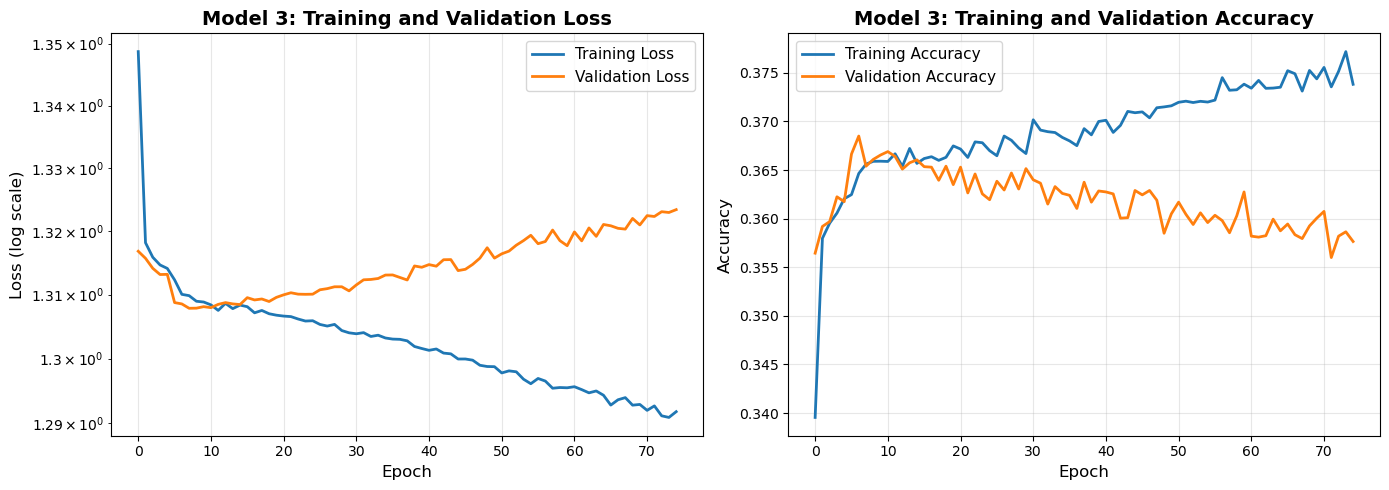

In [11]:
from keras import Input, regularizers

def model_3():
	embedding_configs = {
		'sex': {'vocab_size': 4, 'embed_dim': 2},
		'region': {'vocab_size': 6, 'embed_dim': 3},
		'urban_rural': {'vocab_size': 4, 'embed_dim': 2},
		'education': {'vocab_size': 7, 'embed_dim': 4},
		'marital_status': {'vocab_size': 5, 'embed_dim': 3},
		'employment_status': {'vocab_size': 5, 'embed_dim': 3},
		'smoker': {'vocab_size': 4, 'embed_dim': 2}
	}
	
	inputs = {}
	
	for feature_name in embedding_configs.keys():
		inputs[feature_name] = Input(shape=(1,), dtype=tf.int32, name=feature_name)
	
	numerical_features = ['systolic_bp', 'diastolic_bp', 'ldl', 'hba1c', 'age', 'income', 'bmi']
	for feature_name in numerical_features:
		inputs[feature_name] = Input(shape=(1,), dtype=tf.float32, name=feature_name)
	
	discretized_features = {
		'household_size': 9,
		'dependents': 8,
		'chronic_count': 7,
		'hypertension': 2,
		'diabetes': 2,
		'asthma': 2,
		'copd': 2,
		'cardiovascular_disease': 2,
		'cancer_history': 2,
		'kidney_disease': 2,
		'liver_disease': 2,
		'arthritis': 2,
		'mental_health': 2
	}
	
	for feature_name, num_bins in discretized_features.items():
		inputs[feature_name] = Input(shape=(num_bins,), dtype=tf.float32, name=feature_name)
	
	# Crossed features
	crossed_features = {
		'smoker_X_mental_health': 6,
		'chronic_count_X_region': 35,
		'marital_status_X_sex': 12
	}
	
	for feature_name, dim in crossed_features.items():
		inputs[feature_name] = Input(shape=(dim,), dtype=tf.float32, name=feature_name)
	
	# ========== DEEP BRANCH WITH EMBEDDINGS ==========
	embeddings = []
	for feature_name, config in embedding_configs.items():
		embedding = layers.Embedding(
			input_dim=config['vocab_size'], 
			output_dim=config['embed_dim'], 
			embeddings_regularizer=regularizers.l2(1e-5),
			name=f'embedding_{feature_name}'
		)(inputs[feature_name])
		
		embedding = layers.Flatten(name=f'flatten_{feature_name}')(embedding)
		embeddings.append(embedding)
	
	embedded_features = layers.Concatenate(name='concatenated_embeddings')(embeddings)
	
	numerical_concat = layers.Concatenate(name='numerical_features')(
		[inputs[f] for f in numerical_features]
	)
	
	discretized_concat = layers.Concatenate(name='discretized_features')(
		[inputs[f] for f in discretized_features.keys()]
	)
	
	deep_branch = layers.Concatenate(name='deep_input')(
		[embedded_features, numerical_concat, discretized_concat]
	)
	
	deep = layers.Dense(256, activation='relu', name='deep_dense_1')(deep_branch)
	deep = layers.BatchNormalization(name='deep_bn_1')(deep)
	deep = layers.Dropout(0.3, name='deep_dropout_1')(deep)
	
	deep = layers.Dense(128, activation='relu', name='deep_dense_2')(deep)
	deep = layers.BatchNormalization(name='deep_bn_2')(deep)
	deep = layers.Dropout(0.3, name='deep_dropout_2')(deep)
	
	deep = layers.Dense(64, activation='relu', name='deep_dense_3')(deep)
	deep = layers.BatchNormalization(name='deep_bn_3')(deep)
	deep = layers.Dropout(0.3, name='deep_dropout_3')(deep)
	
	deep = layers.Dense(32, activation='relu', name='deep_dense_4')(deep)
	deep = layers.BatchNormalization(name='deep_bn_4')(deep)
	deep = layers.Dropout(0.3, name='deep_dropout_4')(deep)
	
	wide_features = []
	
	for feature_name in crossed_features.keys():
		wide_features.append(inputs[feature_name])
	
	wide_features.extend([
		inputs['age'],
		inputs['income'],
		inputs['bmi'],
		inputs['chronic_count']
	])
	
	wide = layers.Concatenate(name='wide_input')(wide_features)
	wide = layers.Dense(64, activation="linear", name="wide_linear")(wide)
	
	# ========== COMBINE WIDE AND DEEP ==========
	combined = layers.Concatenate(name='wide_and_deep')([wide, deep])
	
	combined = layers.Dense(64, activation='relu', name='combined_dense')(combined)
	combined = layers.Dropout(0.2, name='combined_dropout')(combined)
	
	# Output layer
	output = layers.Dense(4, activation='softmax', name='output')(combined)
	
	model = tf.keras.Model(inputs=inputs, outputs=output)
	
	return model

model3 = model_3()

model3.compile(
	optimizer=tf.keras.optimizers.Adam(learning_rate=0.002),
	loss='sparse_categorical_crossentropy',
	metrics=['accuracy']
)

history3 = model3.fit(
	preprocessed_ds_train_emb,
	validation_data=preprocessed_ds_test_emb,
	epochs=75,
	verbose=1
)

model3.summary()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Loss plot (log scale)
axes[0].semilogy(history3.history['loss'], label='Training Loss', linewidth=2)
axes[0].semilogy(history3.history['val_loss'], label='Validation Loss', linewidth=2)
axes[0].set_xlabel('Epoch', fontsize=12)
axes[0].set_ylabel('Loss (log scale)', fontsize=12)
axes[0].set_title('Model 3: Training and Validation Loss', fontsize=14, fontweight='bold')
axes[0].legend(fontsize=11)
axes[0].grid(True, alpha=0.3)

# Accuracy plot
axes[1].plot(history3.history['accuracy'], label='Training Accuracy', linewidth=2)
axes[1].plot(history3.history['val_accuracy'], label='Validation Accuracy', linewidth=2)
axes[1].set_xlabel('Epoch', fontsize=12)
axes[1].set_ylabel('Accuracy', fontsize=12)
axes[1].set_title('Model 3: Training and Validation Accuracy', fontsize=14, fontweight='bold')
axes[1].legend(fontsize=11)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

#### Analysis For Model 3

Model 3 is a 4 layer wide and deep network with. The wide branch only has the crossed features along with age, income, bmi, and chronic count, and the deep branch consists of 4 relu activation dense layer from 256 -> 128 -> 64 -> 32 neurons, which allows the model to learn nonlinear relationship. In addition, the model uses AdaM optimizer with sparse categorical cross-entropy, which works well with multi class classification, and each layer also includes batch normalization and dropout.

The reason being as age, income, bmi, and chronic count are key features used to predict the annual insurance cost. As age would be the main feature as an older person is prone to having an illness, income would affect how much a person can afford for the insurance cost, bmi are a known risk factor, and chronic count is the number of condition the person has which could affect the cost of the insurance. 

According to the summary of the model, it contains 68,872 trainable parameters with 960 non trainable parameters. Additional 137,746 parameters are maintained by AdaM to keep track of the first and second moments estimates. This reduction in parameters is due to us embedding these features into a small vector. This reduces the input dimensionality but also lowers the number of weights in the deep layers. 

From the training curves, we can see that the model 3 is still overfitting the dataset, although the graphs look different from the earlier model. The training loss converges as the epochs increase, but the validation loss increases after a few epochs, this indicates that model was able to learn some features but could not generalize well to unknown data. The accuracy graph also further supports this claim. 

Compared to model 1, model 3 shows better stability in the early epochs due to embedding the features but compared to model 2 the validation is still not improving. This shows that embedding also did not improve the predictive performance with the features we have. 

### 2.4 Comparing Each Model

In [ ]:
# Gpt recommended to use Marco F2 Score, and some bug fixes
from sklearn.metrics import fbeta_score
from sklearn.model_selection import StratifiedKFold
import numpy as np

def f2(y_true, y_pred):
	return fbeta_score(y_true, y_pred, beta=2, average='macro')

def cross_validation(build_model_fn, feature_space_config, X, y, k=5, epochs=25):
	folds = StratifiedKFold(n_splits=k, shuffle=True, random_state=42)
	scores = []
	fold = 1
	
	for train_idx, val_idx in folds.split(X, y):
		print(f"\n=== Fold {fold}/{k} ===")
		
		X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
		y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]
		
		train_ds = tf.data.Dataset.from_tensor_slices((dict(X_train), y_train)).batch(128)
		val_ds = tf.data.Dataset.from_tensor_slices((dict(X_val), y_val)).batch(128)
		
		# Create and adapt feature space
		fs = FeatureSpace(**feature_space_config)
		fs.adapt(train_ds.map(lambda x, _: x))
		
		# Preprocess datasets
		train_prep = train_ds.map(lambda feat, lab: (fs(feat), lab))
		val_prep = val_ds.map(lambda feat, lab: (fs(feat), lab))
		
		model = None
		# Build model
		encoded_inputs = fs.get_encoded_features()
		if build_model_fn.__name__  == "model_3":
			model = build_model_fn()
		else:
			model = build_model_fn(encoded_inputs)
		
		# Compile model
		model.compile(
				optimizer="adam",
				loss="sparse_categorical_crossentropy",
				metrics=["accuracy"]
		)
		
		model.fit(train_prep, epochs=epochs, verbose=0)
		
		y_pred_list = []
		y_true_list = []
		
		for batch_features, batch_labels in val_prep:
				predictions = model.predict(batch_features, verbose=0)
				y_pred_list.append(np.argmax(predictions, axis=1))
				y_true_list.append(batch_labels.numpy())
		
		y_pred = np.concatenate(y_pred_list)
		y_true = np.concatenate(y_true_list)
		
		score = f2(y_true, y_pred)
		scores.append(score)
		
		fold += 1
	
	return np.array(scores)

In [ ]:
feature_space_config = {
	"features": {

		"sex": FeatureSpace.string_categorical(num_oov_indices=1),
		"region": FeatureSpace.string_categorical(num_oov_indices=1),
		"urban_rural": FeatureSpace.string_categorical(num_oov_indices=1),
		"education": FeatureSpace.string_categorical(num_oov_indices=1),
		"marital_status": FeatureSpace.string_categorical(num_oov_indices=1),
		"employment_status": FeatureSpace.string_categorical(num_oov_indices=1),
		"smoker": FeatureSpace.string_categorical(num_oov_indices=1),

		"systolic_bp": FeatureSpace.float_normalized(),
		"diastolic_bp": FeatureSpace.float_normalized(),
		"ldl": FeatureSpace.float_normalized(),
		"hba1c": FeatureSpace.float_normalized(),
		"age": FeatureSpace.float_normalized(),
		"income": FeatureSpace.float_normalized(),
		"bmi": FeatureSpace.float_normalized(),

		"household_size": FeatureSpace.float_discretized(num_bins=9),
		"dependents": FeatureSpace.float_discretized(num_bins=8),
		"chronic_count": FeatureSpace.float_discretized(num_bins=7),

		"hypertension": FeatureSpace.float_discretized(num_bins=2),
		"diabetes": FeatureSpace.float_discretized(num_bins=2),
		"asthma": FeatureSpace.float_discretized(num_bins=2),
		"copd": FeatureSpace.float_discretized(num_bins=2),
		"cardiovascular_disease": FeatureSpace.float_discretized(num_bins=2),
		"cancer_history": FeatureSpace.float_discretized(num_bins=2),
		"kidney_disease": FeatureSpace.float_discretized(num_bins=2),
		"liver_disease": FeatureSpace.float_discretized(num_bins=2),
		"arthritis": FeatureSpace.float_discretized(num_bins=2),
		"mental_health": FeatureSpace.float_discretized(num_bins=2),
	},

	"crosses": [
		FeatureSpace.cross(('smoker', 'mental_health'), crossing_dim=6),
		FeatureSpace.cross(('chronic_count', 'region'),  crossing_dim=35),
		FeatureSpace.cross(('marital_status', 'sex'),    crossing_dim=12),
	],

	"output_mode": "concat",
}

feature_space_config_model3 = {
	'features': {
		"sex": FeatureSpace.string_categorical(num_oov_indices=1, output_mode="int"),
		"region": FeatureSpace.string_categorical(num_oov_indices=1, output_mode="int"),
		"urban_rural": FeatureSpace.string_categorical(num_oov_indices=1, output_mode="int"),
		"education": FeatureSpace.string_categorical(num_oov_indices=1, output_mode="int"),
		"marital_status": FeatureSpace.string_categorical(num_oov_indices=1, output_mode="int"),
		"employment_status": FeatureSpace.string_categorical(num_oov_indices=1, output_mode="int"),
		"smoker": FeatureSpace.string_categorical(num_oov_indices=1, output_mode="int"),
		
		"systolic_bp": FeatureSpace.float_normalized(),
		"diastolic_bp": FeatureSpace.float_normalized(),
		"ldl": FeatureSpace.float_normalized(),
		"hba1c": FeatureSpace.float_normalized(),
		"age": FeatureSpace.float_normalized(),
		"income": FeatureSpace.float_normalized(),
		"bmi": FeatureSpace.float_normalized(),
		"household_size": FeatureSpace.float_discretized(num_bins=9),
		"dependents": FeatureSpace.float_discretized(num_bins=8),
		"chronic_count": FeatureSpace.float_discretized(num_bins=7),
		"hypertension": FeatureSpace.float_discretized(num_bins=2),
		"diabetes": FeatureSpace.float_discretized(num_bins=2),
		"asthma": FeatureSpace.float_discretized(num_bins=2),
		"copd": FeatureSpace.float_discretized(num_bins=2),
		"cardiovascular_disease": FeatureSpace.float_discretized(num_bins=2),
		"cancer_history": FeatureSpace.float_discretized(num_bins=2),
		"kidney_disease": FeatureSpace.float_discretized(num_bins=2),
		"liver_disease": FeatureSpace.float_discretized(num_bins=2),
		"arthritis": FeatureSpace.float_discretized(num_bins=2),
		"mental_health": FeatureSpace.float_discretized(num_bins=2),
	},
	'crosses': [
		FeatureSpace.cross(feature_names=('smoker', 'mental_health'), crossing_dim=6),
		FeatureSpace.cross(feature_names=('chronic_count', 'region'), crossing_dim=35),
		FeatureSpace.cross(feature_names=('marital_status', 'sex'), crossing_dim=12),
	],
	'output_mode': "dict"
}

In [21]:
f2_m1 = cross_validation(model_1, feature_space_config, X_train, y_train, 3, 70)
f2_m2 = cross_validation(model_2, feature_space_config, X_train, y_train, 3, 70)
f2_m3 = cross_validation(model_3, feature_space_config_model3, X_train, y_train, 3, 70)

print("Model 1 F2:", f2_m1.mean())
print("Model 2 F2:", f2_m2.mean())
print("Model 3 F2:", f2_m3.mean())


=== Fold 1/3 ===
Fold 1 F2 Score: 0.3204

=== Fold 2/3 ===
Fold 2 F2 Score: 0.3176

=== Fold 3/3 ===
Fold 3 F2 Score: 0.3152

=== Fold 1/3 ===
Fold 1 F2 Score: 0.3368

=== Fold 2/3 ===
Fold 2 F2 Score: 0.3418

=== Fold 3/3 ===
Fold 3 F2 Score: 0.3478

=== Fold 1/3 ===
Fold 1 F2 Score: 0.3435

=== Fold 2/3 ===
Fold 2 F2 Score: 0.3414

=== Fold 3/3 ===
Fold 3 F2 Score: 0.3392
Model 1 F2: 0.31776681501350384
Model 2 F2: 0.34212119627444587
Model 3 F2: 0.3413618182758382


#### Evaluation Analysis. 

We chose 3 fold for Stratified K Fold as this is a good balance of computation time as running each model takes approximately 2-3 mins to run, and in addition it can provide a good statistical result. In addition, we choose an epoch as 70 as all three models seem to converge fast, but validation slowly decreases which shows the true performance of the model. 

From running the cross validation with a fold of 3, and using Marco f2 score, we see that model 2 achieved the best result (0.342) albeit slightly compared to model 3 (0.341). Model 1 performed the worst out of all them with a value of 0.318. Despite using embedding in model 3 it was ever so slightly worse than model 2. This is likely due to some weights of the categorical features did not perform well with the embedding of those features. Model 2 uses of batch normalization and dropout also likely improved regularization and stability giving it a slight performance improvement. This is supported by validation accuracy performing better in model 2, compared to model 3, while it is not a truw accurate result, it does give an insight how well it performs. 

As such, we will be going with model 2 as the best performer

#### Conclusion

From these results, we can see that the model is really struggling to predict annual_medical_cost_level feature. While adding more layers did improve the model, but it did not make it much better and say minimal improvement. Moreover, embedding, and introducing dropout did not provide better results either with their validation accuracy.

### 2.5 Comparing Our Best Model Against a standard MLP

Epoch 1/70
625/625 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.3585 - loss: 1.3166 - val_accuracy: 0.3677 - val_loss: 1.3104
Epoch 2/70
625/625 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.3664 - loss: 1.3079 - val_accuracy: 0.3621 - val_loss: 1.3103
Epoch 3/70
625/625 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.3663 - loss: 1.3060 - val_accuracy: 0.3664 - val_loss: 1.3110
Epoch 4/70
625/625 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.3694 - loss: 1.3043 - val_accuracy: 0.3670 - val_loss: 1.3123
Epoch 5/70
625/625 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.3699 - loss: 1.3020 - val_accuracy: 0.3643 - val_loss: 1.3124
Epoch 6/70
625/625 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.3740 - loss: 1.2991 - val_accuracy: 0.3602 - val_loss: 1.3137
Epoch 7/70
625/625 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.3795 - loss: 1.2949 - val_accuracy: 0.3573 - val_loss: 1.3177
Epoch 8/70
625/625 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.3839 - loss: 1.2903 - val_accuracy: 0.

Model: "functional_38"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ keras_tensor_53CLONE            │ (None, 139)            │             0 │
│ (InputLayer)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mlp_dense_1 (Dense)             │ (None, 256)            │        35,840 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mlp_dense_2 (Dense)             │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mlp_dense_3 (Dense)             │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mlp_dense_4 (Dense)             │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mlp_output (Dense)              │ (None, 4)              │           132 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 237,614 (928.18 KB)

 Trainable params: 79,204 (309.39 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 158,410 (618.79 KB)

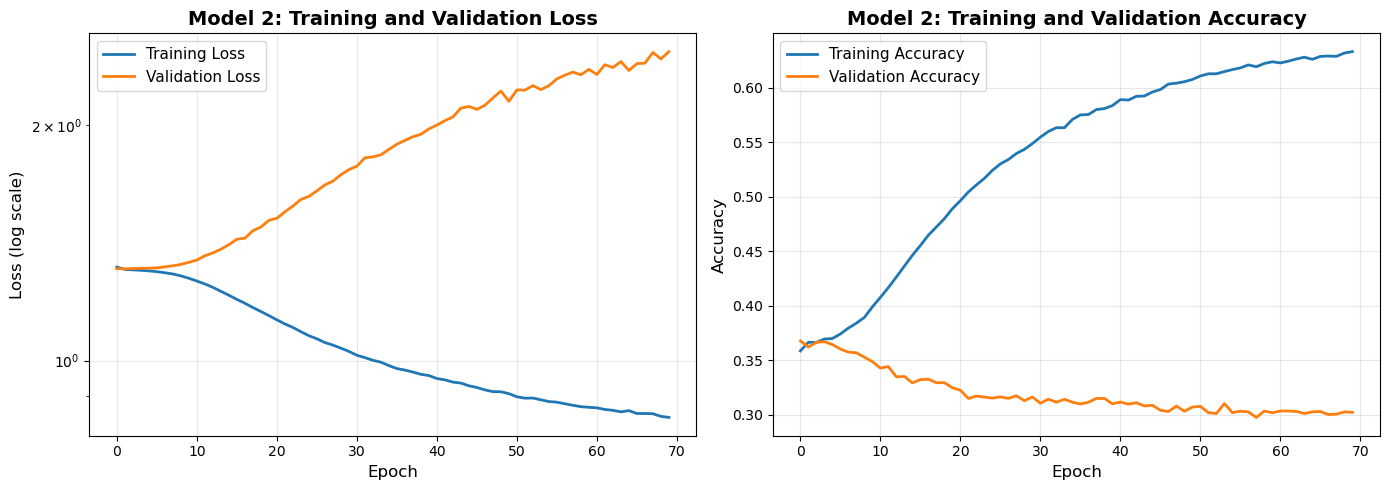

In [32]:
def four_layer_MLP(inputs):
	layer1 = tf.keras.layers.Dense(256, activation="relu", name="mlp_dense_1")(inputs)
	layer2 = tf.keras.layers.Dense(128, activation="relu", name="mlp_dense_2")(layer1)
	layer3 = tf.keras.layers.Dense(64, activation="relu", name="mlp_dense_3")(layer2)
	layer4 = tf.keras.layers.Dense(32, activation="relu", name="mlp_dense_4")(layer3)
	
	output = tf.keras.layers.Dense(4, activation="softmax", name="mlp_output")(layer4)
	
	model = tf.keras.Model(inputs=inputs, outputs=output)

	return model

encoded_inputs = feature_space.get_encoded_features()
four_mlp_model = four_layer_MLP(encoded_inputs)

four_mlp_model.compile(
			optimizer="adam",
			loss="sparse_categorical_crossentropy",
			metrics=["accuracy"]
	)

history_mlp = four_mlp_model.fit(
		preprocessed_ds_train,
		validation_data=preprocessed_ds_test,
		epochs=70,
		verbose=1
)

four_mlp_model.summary()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Loss plot (log scale)
axes[0].semilogy(history_mlp.history['loss'], label='Training Loss', linewidth=2)
axes[0].semilogy(history_mlp.history['val_loss'], label='Validation Loss', linewidth=2)
axes[0].set_xlabel('Epoch', fontsize=12)
axes[0].set_ylabel('Loss (log scale)', fontsize=12)
axes[0].set_title('Model 2: Training and Validation Loss', fontsize=14, fontweight='bold')
axes[0].legend(fontsize=11)
axes[0].grid(True, alpha=0.3)

# Accuracy plot
axes[1].plot(history_mlp.history['accuracy'], label='Training Accuracy', linewidth=2)
axes[1].plot(history_mlp.history['val_accuracy'], label='Validation Accuracy', linewidth=2)
axes[1].set_xlabel('Epoch', fontsize=12)
axes[1].set_ylabel('Accuracy', fontsize=12)
axes[1].set_title('Model 2: Training and Validation Accuracy', fontsize=14, fontweight='bold')
axes[1].legend(fontsize=11)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:
#Asked gpt for some bug fix
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize

def create_roc_auroc_cv(build_model_fn, feature_space_config, X, y, function_name, n_folds=3, epochs=25):
  fold = StratifiedKFold(n_splits=n_folds, shuffle=True, random_state=42)
  n_classes = 4
  scores = []
  fold_results = []
  
  print(f"\n{'='*80}")
  print(f"Evaluating: {function_name}")
  print(f"{'='*80}")
  
  for fold_idx, (train_idx, val_idx) in enumerate(fold.split(X, y), 1):
    print(f"\nProcessing Fold {fold_idx}/{n_folds}...")
    
    X_train_fold, X_val_fold = X.iloc[train_idx], X.iloc[val_idx]
    y_train_fold, y_val_fold = y.iloc[train_idx], y.iloc[val_idx]
    
    train_ds = tf.data.Dataset.from_tensor_slices((dict(X_train_fold), y_train_fold)).batch(128)
    val_ds = tf.data.Dataset.from_tensor_slices((dict(X_val_fold), y_val_fold)).batch(128)
    
    fs = FeatureSpace(**feature_space_config)
    fs.adapt(train_ds.map(lambda x, _: x))
    
    train_prep = train_ds.map(lambda feat, lab: (fs(feat), lab))
    val_prep = val_ds.map(lambda feat, lab: (fs(feat), lab))
    
    encoded_inputs = fs.get_encoded_features()
    model = build_model_fn(encoded_inputs)
    
    model.compile(
      optimizer="adam",
      loss="sparse_categorical_crossentropy",
      metrics=["accuracy"]
    )
    
    model.fit(train_prep, epochs=epochs, verbose=0)
    
    y_pred_probs = []
    y_true_labels = []
    
    for batch_features, batch_labels in val_prep:
      predictions = model.predict(batch_features, verbose=0)
      y_pred_probs.append(predictions)
      y_true_labels.append(batch_labels.numpy())
    
    y_pred_prob = np.concatenate(y_pred_probs)
    y_true = np.concatenate(y_true_labels)
    
    y_pred_labels = np.argmax(y_pred_prob, axis=1)
    fold_f2 = f2(y_true, y_pred_labels)
    scores.append(fold_f2)
    
    y_true_bin = label_binarize(y_true, classes=[0, 1, 2, 3])
    
    fold_results.append({
      'y_true_bin': y_true_bin,
      'y_pred_prob': y_pred_prob,
      'fold': fold_idx
    })
  
  scores = np.array(scores)
  
  
  print(f"\nGenerating ROC curves...")
  fig, axes = plt.subplots(2, 2, figsize=(16, 14))
  axes = axes.flatten()
  
  colors = ['blue', 'green', 'red', 'purple', 'orange']
  #Asked gpt for help with the plot
  for class_idx in range(n_classes):
    ax = axes[class_idx]
    
    for fold_data in fold_results:
      y_true_bin = fold_data['y_true_bin']
      y_pred_prob = fold_data['y_pred_prob']  # Use probabilities for ROC
      fold_num = fold_data['fold']
      
      fpr, tpr, _ = roc_curve(y_true_bin[:, class_idx], y_pred_prob[:, class_idx])
      roc_auc = auc(fpr, tpr)
      
      ax.plot(fpr, tpr, lw=2, 
          label=f"Fold {fold_num} (AUROC = {roc_auc:.3f})",
          color=colors[fold_num - 1])
    
    ax.plot([0, 1], [0, 1], linestyle='--', color='gray', lw=1, label='Random Classifier')
    
    ax.set_xlabel("False Positive Rate", fontsize=12)
    ax.set_ylabel("True Positive Rate", fontsize=12)
    ax.set_title(f"{function_name}\nClass {class_idx} ROC Curves", fontsize=14, fontweight='bold')
    ax.legend(loc='lower right', fontsize=10)
    ax.grid(True, alpha=0.3)
    ax.set_xlim([0.0, 1.0])
    ax.set_ylim([0.0, 1.05])
  
  plt.tight_layout()
  plt.savefig(f'{function_name.replace(" ", "_")}_ROC_CV.png', dpi=300, bbox_inches='tight')
  plt.show()
  
  for class_idx in range(n_classes):
    aucs_per_class = []
    for fold_data in fold_results:
      y_true_bin = fold_data['y_true_bin']
      y_pred_prob = fold_data['y_pred_prob']
      fpr, tpr, _ = roc_curve(y_true_bin[:, class_idx], y_pred_prob[:, class_idx])
      roc_auc = auc(fpr, tpr)
      aucs_per_class.append(roc_auc)
    
    mean_auc = np.mean(aucs_per_class)
    std_auc = np.std(aucs_per_class)
    print(f"Class {class_idx}: Mean AUROC = {mean_auc:.4f} (±{std_auc:.4f})")
  
  
  return scores

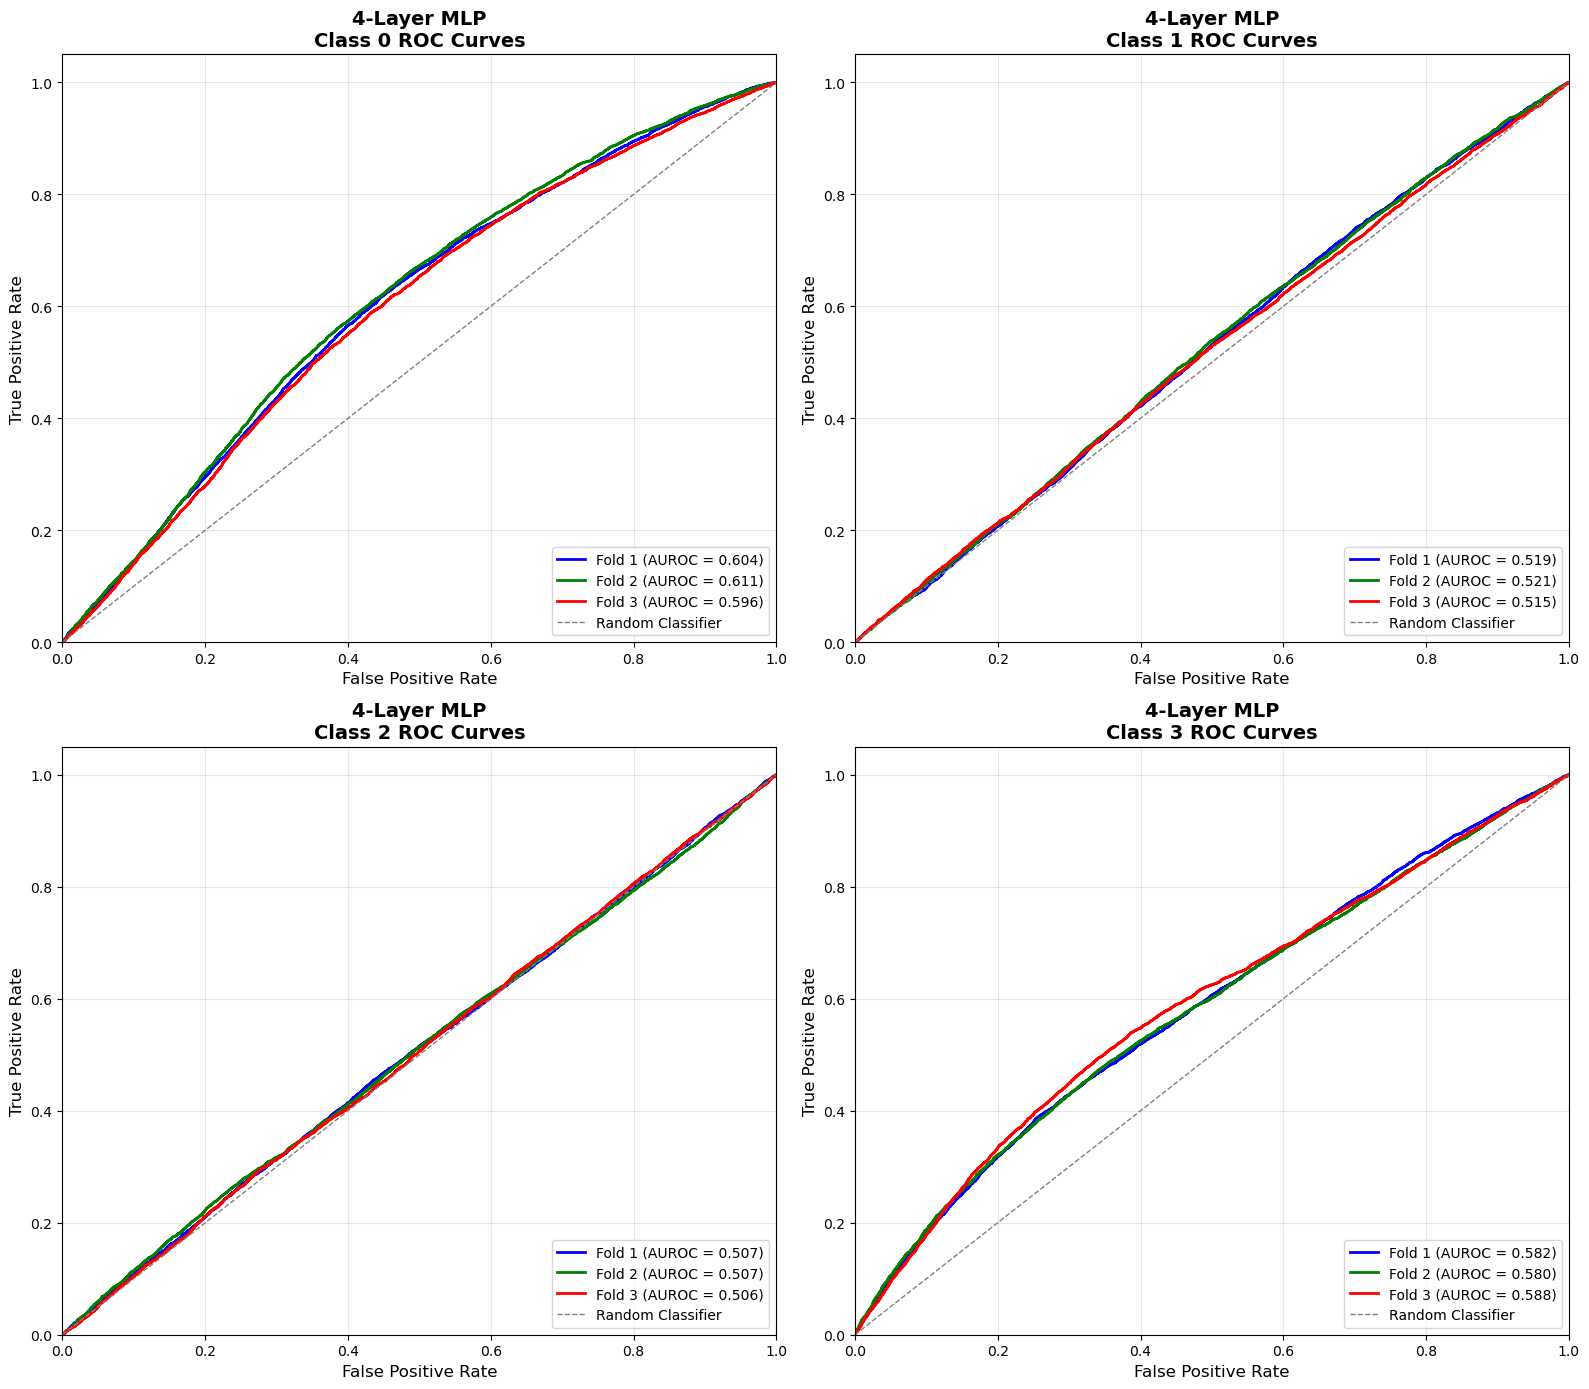

Class 0: Mean AUROC = 0.6038 (±0.0062)
Class 1: Mean AUROC = 0.5182 (±0.0024)
Class 2: Mean AUROC = 0.5066 (±0.0007)
Class 3: Mean AUROC = 0.5835 (±0.0034)


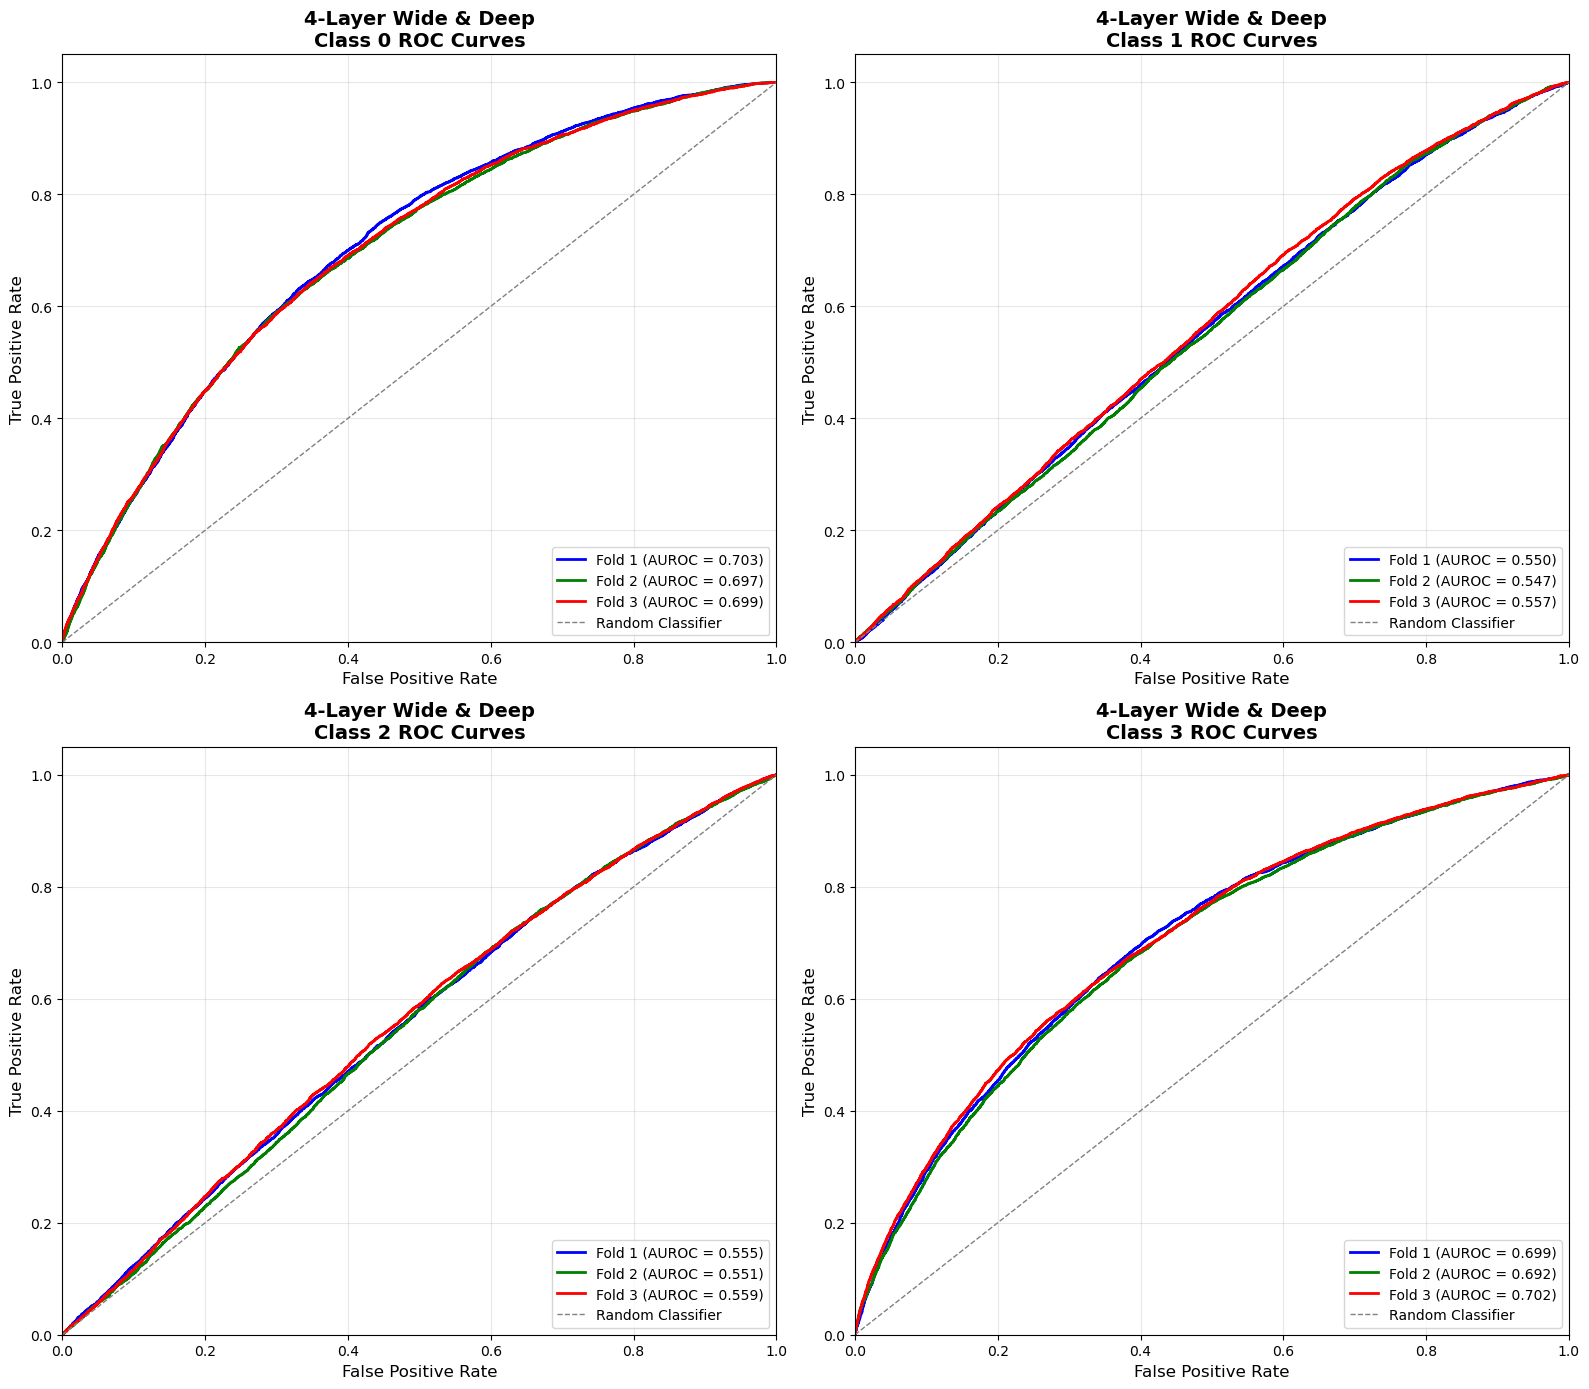

Class 0: Mean AUROC = 0.6994 (±0.0027)
Class 1: Mean AUROC = 0.5514 (±0.0044)
Class 2: Mean AUROC = 0.5550 (±0.0032)
Class 3: Mean AUROC = 0.6975 (±0.0041)


In [35]:
four_layer_mlp_f2 = create_roc_auroc_cv(
		build_model_fn=four_layer_MLP,
		feature_space_config=feature_space_config,
		X=X_train,
		y=y_train,
		function_name="4-Layer MLP",
		n_folds=3,
		epochs=70
)

model_2_f2 = create_roc_auroc_cv(
		build_model_fn=model_2,
		feature_space_config=feature_space_config,
		X=X_train,
		y=y_train,
		function_name="4-Layer Wide & Deep",
		n_folds=3,
		epochs=70
)

#### ROC Analysis

From the graph, we can see that the standard MLP is randomly guessing class 1, and 2 target labels, as indicated by it being closed to the diagonal line or on it Class 0, 3 did show a better result, but the curve is still slightly above the diagonal line so the model is still struggling to predict the correct labels.

Model 2 did perform better than MLP model, but slightly. Model 2 ROC curves clearly show that the curve shifts towards the top left for class 0, amd class 3 is much stronger than in model 1. Class 1, 2 which MLP struggle with was also performing better in model 2 from looking at the curve. 

This is expected as the model 2 has dropout, and batch normalization that helps with the model overfitting, compared to not having one. As such having a batch normalization, and dropout is helpful for the model. Additionally, the wide branch provides memorization for simple relationship, which also helps the model in predicting the result. 

Moreover, the Mean AUROC also indicated that model 2 is better as across all the layer, the model has a higher value than MLP model.

## 3. Exceptional Work

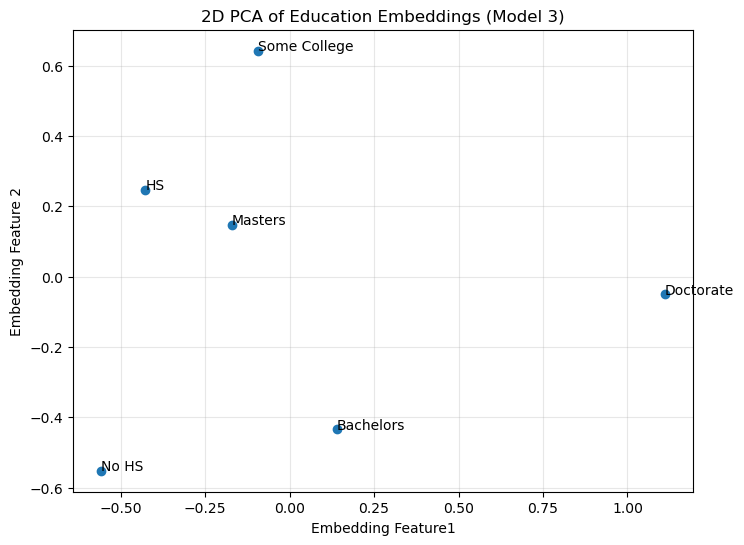

In [38]:
# get weights https://stackoverflow.com/questions/43715047/how-do-i-get-the-weights-of-a-layer-in-keras

from sklearn.decomposition import PCA

# get embedding weights
edu_weights = model3.get_layer("embedding_education").get_weights()[0]

# gpt suggest throw UNK
edu_type_no_unk = feature_space_for_model3.preprocessors["education"].get_vocabulary()[1:]
edu_weight_no_unk = edu_weights[1:, :]

# pca to 2d
pca = PCA(n_components=2)
edu_pca = pca.fit_transform(edu_weight_no_unk)

plt.figure(figsize=(8, 6))
x = edu_pca[:, 0]
y = edu_pca[:, 1]
plt.scatter(x, y)

for i, label in enumerate(edu_type_no_unk):
	plt.text(x[i], y[i], label)

plt.title("2D PCA of Education Embeddings (Model 3)")
plt.xlabel("Embedding Feature1")
plt.ylabel("Embedding Feature 2")
plt.grid(True, alpha=0.3)
plt.show()

We chose education for embedding visualization because it is an important socioeconomic indicators in our dataset, and it has six unique values that may be easier to catch the cluster pattern.

According to the plot, we can see that the model learned meaningful relationships among different education levels, although the clusters are not significantly sharp:
1.	“No HS” and “Doctorate” lie far from the other categories. These two groups represent the extremes of socioeconomic status, with "No High School" associated with lower income, poor health condition and higher medical cost, while "Doctorate" with higher income, elder age, and different lifestyle patterns, so the model places them apart.
2.	"HS","Masters" and "Some college" appear closer to one another. These groups tend to share similar income ranges, age distributions, and access to healthcare, which leads the model to encode them in a more central and overlapping region.

We also notice that the clusters vary slightly after retraining. For example, “Bachelors” sometimes appears near “Masters” and sometimes does not, and “HS” may cluster with “Some College” in one run but separate in another. This suggests that the learned embedding space for education is not fully stable, indicating that this feature may not provide a strong or consistent signal for the model.
